In [1]:
import pandas as pd
df = pd.read_csv("housing.csv")
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [2]:
# Data Cleaning
print("Missing values:\n", df.isnull().sum())

# Fill missing total_bedrooms with median
df['total_bedrooms'].fillna(df['total_bedrooms'].median(), inplace=True)

# Derived features
df['rooms_per_household'] = df['total_rooms'] / df['households']
df['bedrooms_per_room'] = df['total_bedrooms'] / df['total_rooms']
df['population_density'] = df['population'] / df['households']

print("\nData shape:", df.shape)
print("\nNew features added:")
print(df[['rooms_per_household', 'bedrooms_per_room', 'population_density']].head())

Missing values:
 longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

Data shape: (20640, 13)

New features added:
   rooms_per_household  bedrooms_per_room  population_density
0             6.984127           0.146591            2.555556
1             6.238137           0.155797            2.109842
2             8.288136           0.129516            2.802260
3             5.817352           0.184458            2.547945
4             6.281853           0.172096            2.181467


/tmp/ipykernel_10716/415478571.py:5: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['total_bedrooms'].fillna(df['total_bedrooms'].median(), inplace=True)


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Set consistent color scheme
sns.set_theme(style="whitegrid")
COLOR = "#2E75B6"

# Reload and clean properly (avoids chained assignment warning)
df = pd.read_csv("housing.csv")
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())

# Derived features
df['rooms_per_household'] = df['total_rooms'] / df['households']
df['bedrooms_per_room'] = df['total_bedrooms'] / df['total_rooms']
df['population_density'] = df['population'] / df['households']

print("✅ Data ready! Shape:", df.shape)
print("Missing values remaining:", df.isnull().sum().sum())

✅ Data ready! Shape: (20640, 13)
Missing values remaining: 0


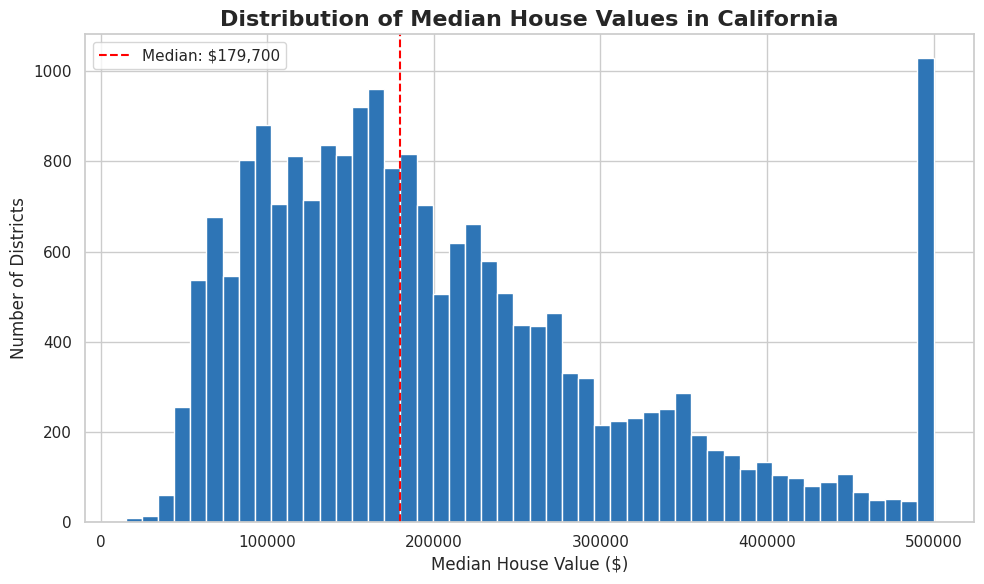

This visualization shows the distribution of median house values across California districts.
This is important because it reveals the overall price range and whether values are skewed.
The key insight is that values are right-skewed, with many districts capped near $500,000.


In [4]:
# Chart 3: Histogram — Distribution of Median House Values
plt.figure(figsize=(10, 6))
plt.hist(df['median_house_value'], bins=50, color=COLOR, edgecolor='white')
plt.title('Distribution of Median House Values in California', fontsize=16, fontweight='bold')
plt.xlabel('Median House Value ($)', fontsize=12)
plt.ylabel('Number of Districts', fontsize=12)
plt.axvline(df['median_house_value'].median(), color='red', linestyle='--', label=f"Median: ${df['median_house_value'].median():,.0f}")
plt.legend()
plt.tight_layout()
plt.savefig('chart3_histogram.png', dpi=150)
plt.show()

print("This visualization shows the distribution of median house values across California districts.")
print("This is important because it reveals the overall price range and whether values are skewed.")
print("The key insight is that values are right-skewed, with many districts capped near $500,000.")

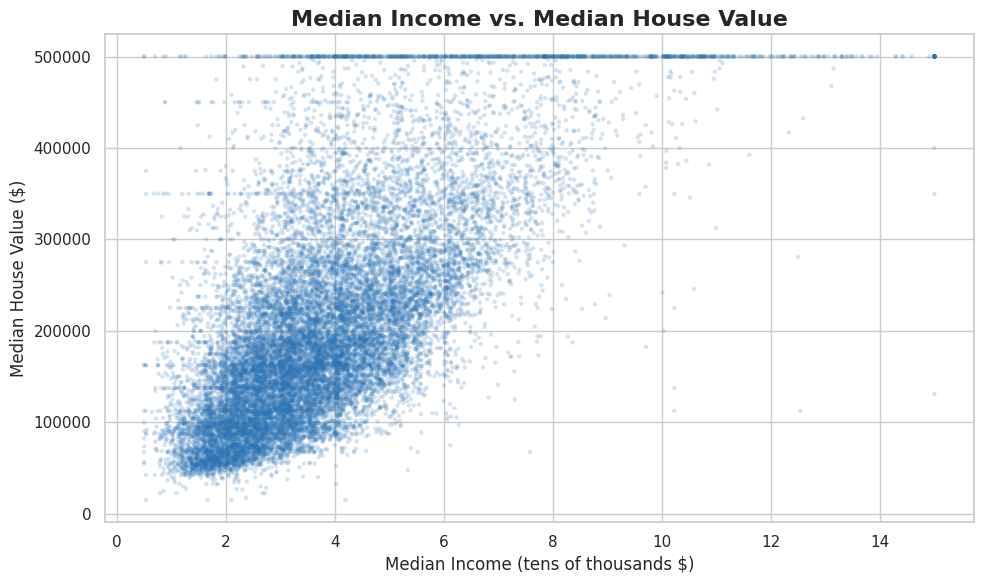

This visualization shows the relationship between household income and house value.
This is important because income is expected to be one of the strongest predictors of housing prices.
The key insight is that there is a clear positive correlation, though with significant spread at higher incomes.


In [5]:
# Chart 4: Scatter Plot — Median Income vs. Median House Value
plt.figure(figsize=(10, 6))
plt.scatter(df['median_income'], df['median_house_value'], 
            alpha=0.2, color=COLOR, edgecolors='none', s=10)
plt.title('Median Income vs. Median House Value', fontsize=16, fontweight='bold')
plt.xlabel('Median Income (tens of thousands $)', fontsize=12)
plt.ylabel('Median House Value ($)', fontsize=12)
plt.tight_layout()
plt.savefig('chart4_scatter.png', dpi=150)
plt.show()

print("This visualization shows the relationship between household income and house value.")
print("This is important because income is expected to be one of the strongest predictors of housing prices.")
print("The key insight is that there is a clear positive correlation, though with significant spread at higher incomes.")

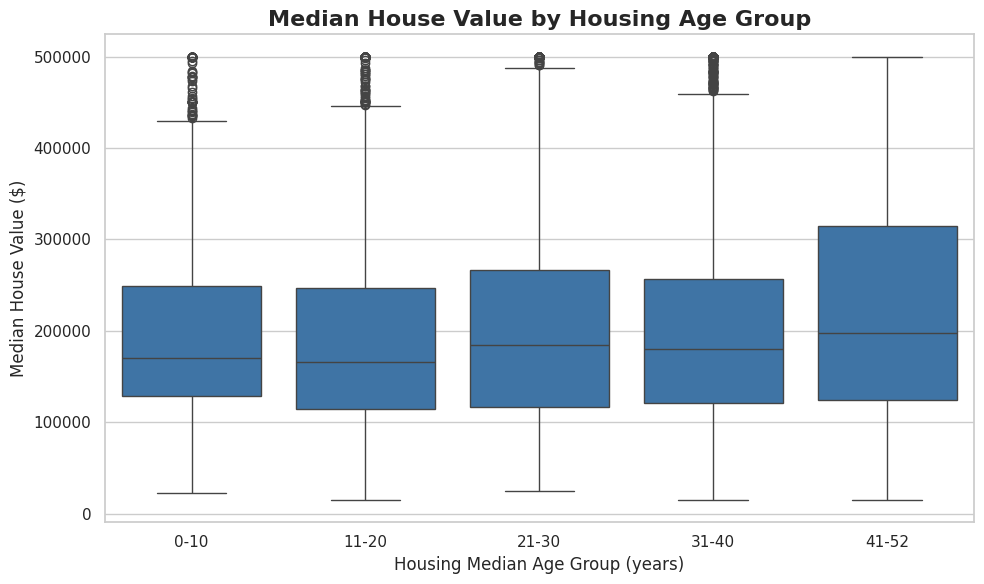

This visualization shows the spread of house values across different housing age groups.
This is important because it reveals whether older or newer homes tend to be valued higher.
The key insight is that older homes (41-52 years) tend to have higher median values, likely due to their urban locations.


In [6]:
# Chart 5: Box Plot — House Value by Housing Age Group
df['age_group'] = pd.cut(df['housing_median_age'], 
                          bins=[0, 10, 20, 30, 40, 52], 
                          labels=['0-10', '11-20', '21-30', '31-40', '41-52'])

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='age_group', y='median_house_value', color=COLOR)
plt.title('Median House Value by Housing Age Group', fontsize=16, fontweight='bold')
plt.xlabel('Housing Median Age Group (years)', fontsize=12)
plt.ylabel('Median House Value ($)', fontsize=12)
plt.tight_layout()
plt.savefig('chart5_boxplot.png', dpi=150)
plt.show()

print("This visualization shows the spread of house values across different housing age groups.")
print("This is important because it reveals whether older or newer homes tend to be valued higher.")
print("The key insight is that older homes (41-52 years) tend to have higher median values, likely due to their urban locations.")

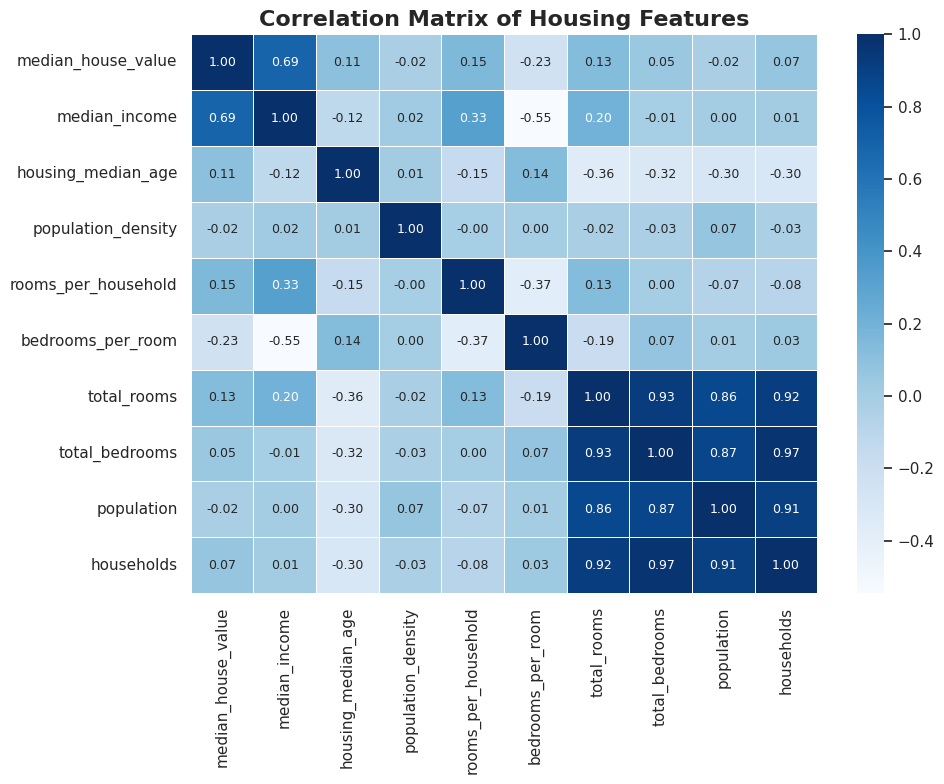

This visualization shows the correlation between all numeric features in the dataset.
This is important because it identifies which variables are most strongly related to house value.
The key insight is that median_income has the strongest positive correlation with median_house_value.


In [7]:
# Chart 8: Heatmap — Correlation Matrix
plt.figure(figsize=(10, 8))
numeric_cols = ['median_house_value', 'median_income', 'housing_median_age', 
                'population_density', 'rooms_per_household', 'bedrooms_per_room',
                'total_rooms', 'total_bedrooms', 'population', 'households']

corr = df[numeric_cols].corr()

sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues',
            linewidths=0.5, annot_kws={"size": 9})
plt.title('Correlation Matrix of Housing Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('chart8_heatmap.png', dpi=150)
plt.show()

print("This visualization shows the correlation between all numeric features in the dataset.")
print("This is important because it identifies which variables are most strongly related to house value.")
print("The key insight is that median_income has the strongest positive correlation with median_house_value.")

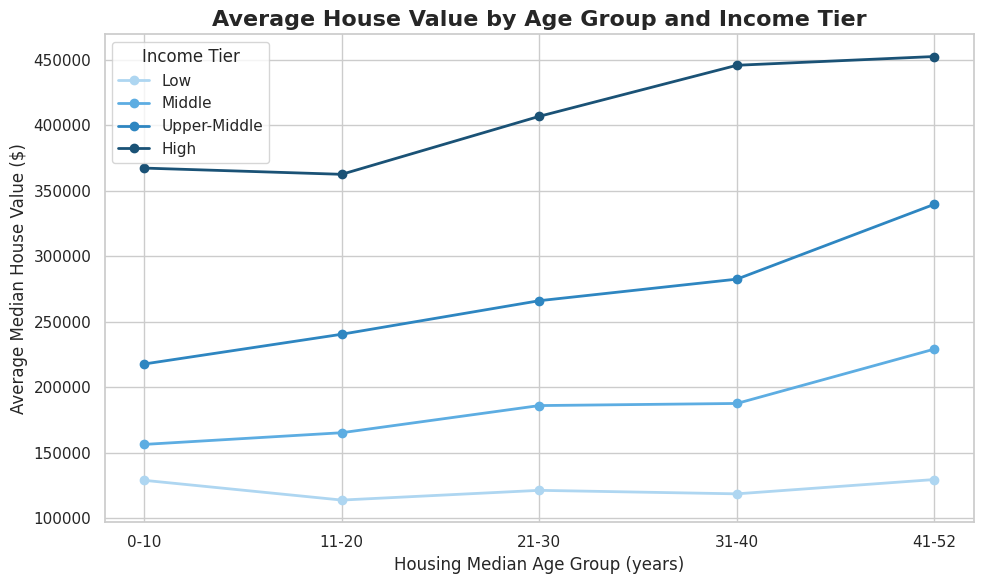

This visualization shows how house values trend across housing age groups for different income tiers.
This is important because it reveals whether income and age interact in their effect on house value.
The key insight is that high-income areas consistently command higher prices regardless of housing age.


In [8]:
# Chart 6: Multi-line Plot — Avg House Value by Age Group across Income Tiers
df['income_tier'] = pd.cut(df['median_income'], 
                            bins=[0, 2.5, 4.5, 6.5, 15], 
                            labels=['Low', 'Middle', 'Upper-Middle', 'High'])

grouped = df.groupby(['age_group', 'income_tier'], observed=True)['median_house_value'].mean().reset_index()

plt.figure(figsize=(10, 6))
for tier, color in zip(['Low', 'Middle', 'Upper-Middle', 'High'], 
                        ['#AED6F1', '#5DADE2', '#2E86C1', '#1A5276']):
    data = grouped[grouped['income_tier'] == tier]
    plt.plot(data['age_group'], data['median_house_value'], 
             marker='o', label=tier, color=color, linewidth=2)

plt.title('Average House Value by Age Group and Income Tier', fontsize=16, fontweight='bold')
plt.xlabel('Housing Median Age Group (years)', fontsize=12)
plt.ylabel('Average Median House Value ($)', fontsize=12)
plt.legend(title='Income Tier')
plt.tight_layout()
plt.savefig('chart6_multiline.png', dpi=150)
plt.show()

print("This visualization shows how house values trend across housing age groups for different income tiers.")
print("This is important because it reveals whether income and age interact in their effect on house value.")
print("The key insight is that high-income areas consistently command higher prices regardless of housing age.")

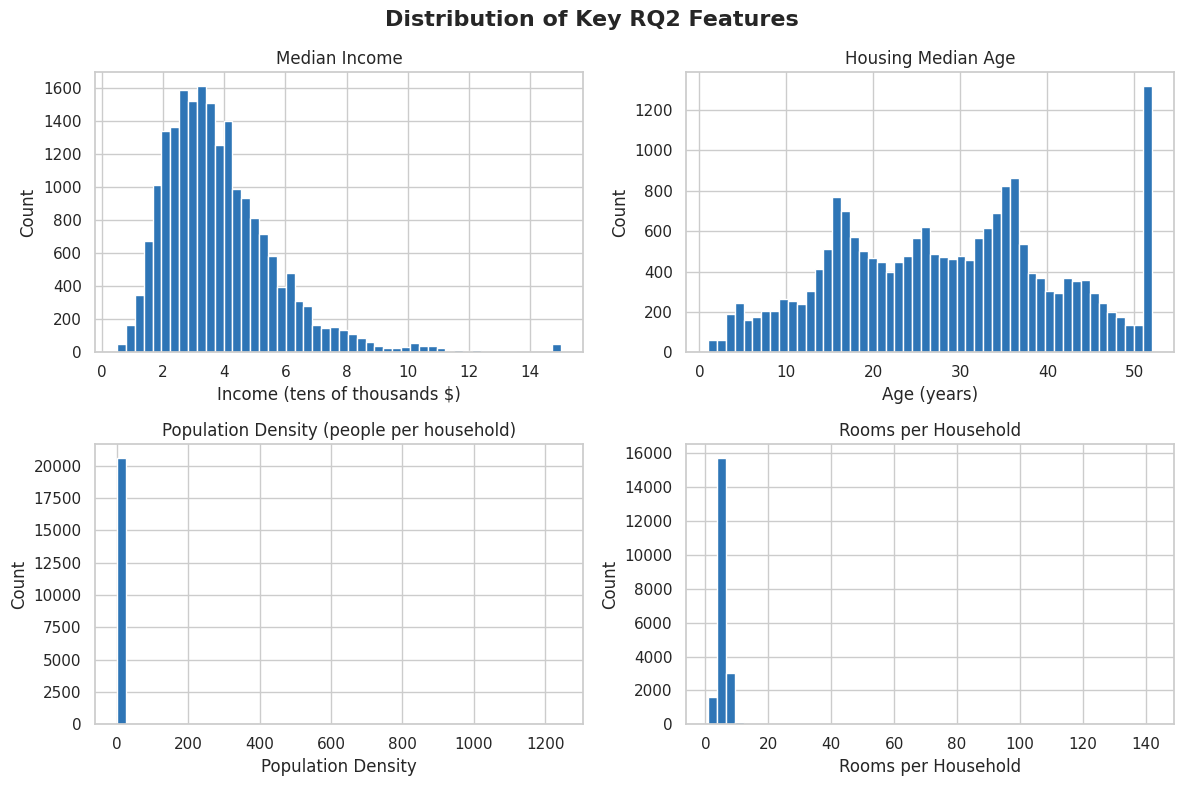

This visualization shows the distribution of the four key features in RQ2.
This is important because it reveals the shape and spread of each variable before analysis.
The key insight is that income and rooms per household are right-skewed, indicating outliers at the high end.


In [9]:
# Chart 7: Faceted Subplot — Distribution of Key RQ2 Features
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Distribution of Key RQ2 Features', fontsize=16, fontweight='bold')

axes[0, 0].hist(df['median_income'], bins=50, color=COLOR, edgecolor='white')
axes[0, 0].set_title('Median Income')
axes[0, 0].set_xlabel('Income (tens of thousands $)')
axes[0, 0].set_ylabel('Count')

axes[0, 1].hist(df['housing_median_age'], bins=50, color=COLOR, edgecolor='white')
axes[0, 1].set_title('Housing Median Age')
axes[0, 1].set_xlabel('Age (years)')
axes[0, 1].set_ylabel('Count')

axes[1, 0].hist(df['population_density'], bins=50, color=COLOR, edgecolor='white')
axes[1, 0].set_title('Population Density (people per household)')
axes[1, 0].set_xlabel('Population Density')
axes[1, 0].set_ylabel('Count')

axes[1, 1].hist(df['rooms_per_household'], bins=50, color=COLOR, edgecolor='white')
axes[1, 1].set_title('Rooms per Household')
axes[1, 1].set_xlabel('Rooms per Household')
axes[1, 1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('chart7_faceted.png', dpi=150)
plt.show()

print("This visualization shows the distribution of the four key features in RQ2.")
print("This is important because it reveals the shape and spread of each variable before analysis.")
print("The key insight is that income and rooms per household are right-skewed, indicating outliers at the high end.")

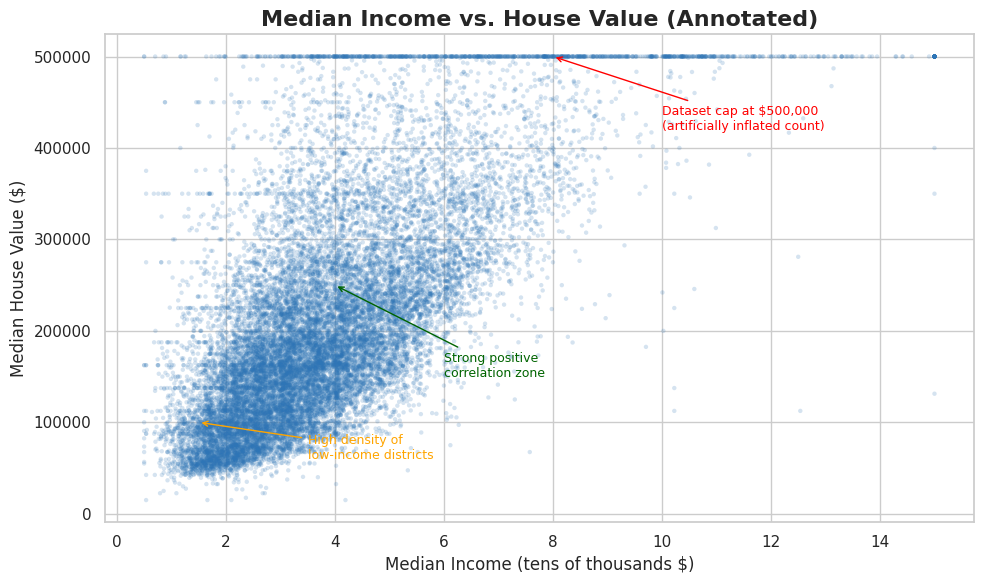

This visualization highlights three key patterns in the income vs. house value relationship.
This is important because annotations guide the reader toward the most meaningful insights.
The key insight is that the $500,000 cap, strong correlation zone, and low-income cluster are all critical to understanding the data.


In [10]:
# Chart 9: Annotated Plot — Income vs House Value with key annotations
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(df['median_income'], df['median_house_value'], 
           alpha=0.2, color=COLOR, edgecolors='none', s=10)

# Annotation 1: Data cap
ax.annotate('Dataset cap at $500,000\n(artificially inflated count)', 
            xy=(8, 500000), xytext=(10, 420000),
            arrowprops=dict(arrowstyle='->', color='red'),
            fontsize=9, color='red')

# Annotation 2: Strong correlation zone
ax.annotate('Strong positive\ncorrelation zone', 
            xy=(4, 250000), xytext=(6, 150000),
            arrowprops=dict(arrowstyle='->', color='darkgreen'),
            fontsize=9, color='darkgreen')

# Annotation 3: Low income cluster
ax.annotate('High density of\nlow-income districts', 
            xy=(1.5, 100000), xytext=(3.5, 60000),
            arrowprops=dict(arrowstyle='->', color='orange'),
            fontsize=9, color='orange')

ax.set_title('Median Income vs. House Value (Annotated)', fontsize=16, fontweight='bold')
ax.set_xlabel('Median Income (tens of thousands $)', fontsize=12)
ax.set_ylabel('Median House Value ($)', fontsize=12)
plt.tight_layout()
plt.savefig('chart9_annotated.png', dpi=150)
plt.show()

print("This visualization highlights three key patterns in the income vs. house value relationship.")
print("This is important because annotations guide the reader toward the most meaningful insights.")
print("The key insight is that the $500,000 cap, strong correlation zone, and low-income cluster are all critical to understanding the data.")

In [12]:
# Interactive Viz #2: Plotly — Feature vs House Value with Dropdown
import plotly.graph_objects as go

features = {
    'Median Income': 'median_income',
    'Housing Median Age': 'housing_median_age',
    'Rooms per Household': 'rooms_per_household',
    'Population Density': 'population_density'
}

fig = go.Figure()

for label, col in features.items():
    fig.add_trace(go.Scatter(
        x=df[col], y=df['median_house_value'],
        mode='markers',
        marker=dict(color='#2E75B6', opacity=0.2, size=4),
        name=label,
        visible=(label == 'Median Income')
    ))

buttons = []
for i, label in enumerate(features.keys()):
    visibility = [j == i for j in range(len(features))]
    buttons.append(dict(
        label=label,
        method='update',
        args=[{'visible': visibility},
              {'xaxis': {'title': label}}]
    ))

fig.update_layout(
    title=dict(text='House Value vs. Selected Feature (Interactive)', y=0.95),
    xaxis_title='Median Income',
    yaxis_title='Median House Value ($)',
    updatemenus=[dict(
        active=0,
        buttons=buttons,
        x=0.0, y=1.0,
        xanchor='left',
        yanchor='bottom'
    )],
    margin=dict(t=100),
    height=550
)

fig.write_html('interactive_viz2.html')
fig.show()

print("Interactive viz saved as interactive_viz2.html")

Interactive viz saved as interactive_viz2.html


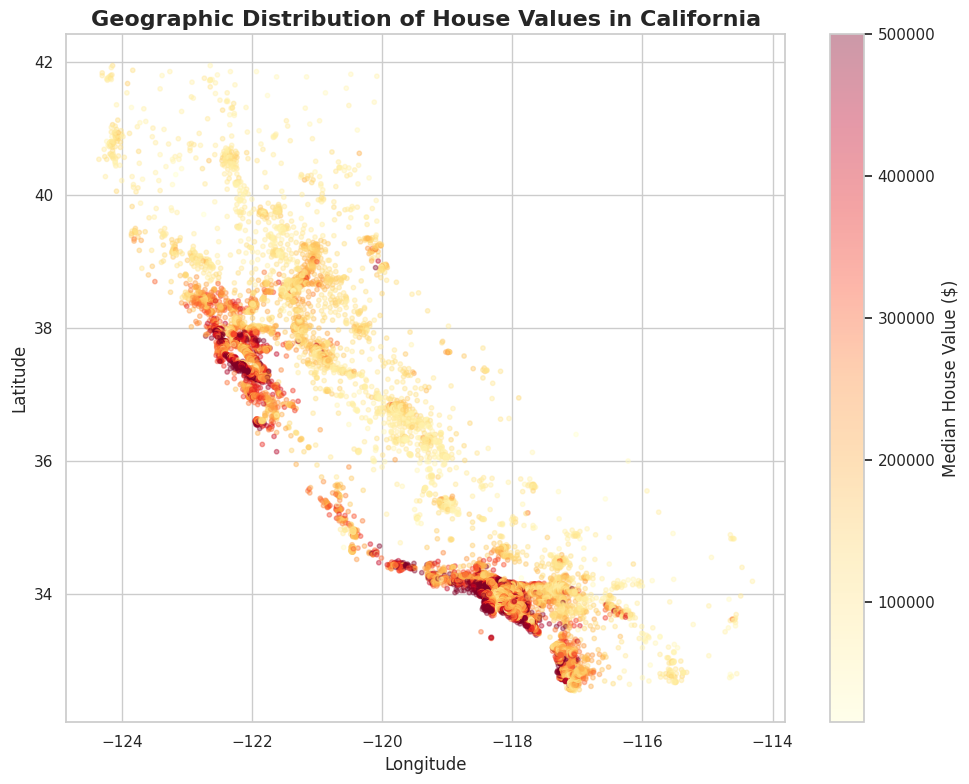

This visualization shows the geographic distribution of house values across California.
This is important because it reveals that location is a major driver of housing prices.
The key insight is that coastal areas, particularly the Bay Area and LA, show the highest values.


In [13]:
# Chart 10: Custom Viz — Geographic Map of House Values
plt.figure(figsize=(10, 8))
scatter = plt.scatter(df['longitude'], df['latitude'], 
                      c=df['median_house_value'], cmap='YlOrRd',
                      alpha=0.4, s=10)
plt.colorbar(scatter, label='Median House Value ($)')
plt.title('Geographic Distribution of House Values in California', fontsize=16, fontweight='bold')
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)
plt.tight_layout()
plt.savefig('chart10_map.png', dpi=150)
plt.show()

print("This visualization shows the geographic distribution of house values across California.")
print("This is important because it reveals that location is a major driver of housing prices.")
print("The key insight is that coastal areas, particularly the Bay Area and LA, show the highest values.")